## 1) Objective

This notebook extends the raw-data overview with deeper data understanding:
- table-level summary and schema checks
- missing-value analysis
- basic distribution plots for order behavior
- quick quality checks before preparation/EDA

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.4f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')

In [3]:
# Resolve data directory robustly whether notebook runs from project root or notebook folder
candidate_dirs = [Path('data/raw'), Path('../../data/raw')]
data_dir = next((p for p in candidate_dirs if p.exists()), None)
if data_dir is None:
    raise FileNotFoundError('Cannot find data/raw directory from current working directory.')

order_products_prior = pd.read_csv(data_dir / 'order_products__prior.csv')
order_products_train = pd.read_csv(data_dir / 'order_products__train.csv')
orders = pd.read_csv(data_dir / 'orders.csv')
products = pd.read_csv(data_dir / 'products.csv')
aisles = pd.read_csv(data_dir / 'aisles.csv')
departments = pd.read_csv(data_dir / 'departments.csv')

tables = {
    'orders': orders,
    'order_products_prior': order_products_prior,
    'order_products_train': order_products_train,
    'products': products,
    'aisles': aisles,
    'departments': departments,
}

print(f'Loaded {len(tables)} tables from: {data_dir.resolve()}')

Loaded 6 tables from: /home/ppt/Desktop/DataAnalyst/Instacart-Market-Basket-Analysis/data/raw


In [4]:
# Create order_date by calculating cumulative days and subtracting from snapshot_date
# Reference: The Instacart dataset snapshot is typically at 2015-07-01
snapshot_date = pd.Timestamp('2015-07-01')

# Create cumulative_days: sum of days_since_prior_order for each user, sorted by order_number
orders_sorted = orders.sort_values(['user_id', 'order_number']).reset_index(drop=True)

# Handle NaN values: first order (order_number=1) has NaN for days_since_prior_order
orders_sorted['days_since_prior_order'] = orders_sorted['days_since_prior_order'].fillna(0)

# Calculate cumulative days for each user
orders_sorted['cumulative_days'] = orders_sorted.groupby('user_id')['days_since_prior_order'].cumsum()

# Calculate order_date by subtracting cumulative_days from snapshot_date
orders_sorted['order_date'] = snapshot_date - pd.to_timedelta(orders_sorted['cumulative_days'], unit='D')

# Restore original row order
orders_with_dates = orders.copy()
orders_with_dates = orders_with_dates.merge(
    orders_sorted[['order_id', 'cumulative_days', 'order_date']], 
    on='order_id', 
    how='left'
)

print(f"✓ Created cumulative_days and order_date columns")
print(f"✓ Snapshot date: {snapshot_date}")
print(f"✓ Date range: {orders_with_dates['order_date'].min()} to {orders_with_dates['order_date'].max()}")
print(f"\nSample rows with dates:")
display(orders_with_dates[['order_id', 'user_id', 'order_number', 'days_since_prior_order', 'cumulative_days', 'order_date']].head(10))

✓ Created cumulative_days and order_date columns
✓ Snapshot date: 2015-07-01 00:00:00
✓ Date range: 2014-07-01 00:00:00 to 2015-07-01 00:00:00

Sample rows with dates:


,order_id,user_id,order_number,days_since_prior_order,cumulative_days,order_date
0,2539329,1,1,NaN,0.0000,2015-07-01
1,2398795,1,2,15.0000,15.0000,2015-06-16
2,473747,1,3,21.0000,36.0000,2015-05-26
3,2254736,1,4,29.0000,65.0000,2015-04-27
4,431534,1,5,28.0000,93.0000,2015-03-30
5,3367565,1,6,19.0000,112.0000,2015-03-11
6,550135,1,7,20.0000,132.0000,2015-02-19
7,3108588,1,8,14.0000,146.0000,2015-02-05
8,2295261,1,9,0.0000,146.0000,2015-02-05
9,2550362,1,10,30.0000,176.0000,2015-01-06


In [ ]:
# Save orders_with_dates to canonical processed/features directory
candidate_roots = [Path('.'), Path('../..')]
project_root = next(
    (p.resolve() for p in candidate_roots if (p / 'src').exists() and (p / 'data').exists()),
    None,
)
if project_root is None:
    raise FileNotFoundError('Could not resolve project root from current notebook working directory.')

output_dir = project_root / 'data' / 'processed' / 'features'
output_dir.mkdir(parents=True, exist_ok=True)

orders_output_path = output_dir / 'orders_with_dates.csv'
orders_with_dates.to_csv(orders_output_path, index=False)

print(f"Saved orders_with_dates to: {orders_output_path}")
print(f"Rows: {len(orders_with_dates):,} | Columns: {len(orders_with_dates.columns)}")

✓ Saved updated orders with dates to:
  /home/ppt/Desktop/DataAnalyst/Instacart-Market-Basket-Analysis/notebooks/01_Data_Understanding/data/processed/orders_with_dates.csv
✓ File size: 156.91 MB
✓ Total rows: 3,421,083
✓ Columns: ['order_id', 'user_id', 'eval_set', 'order_number', 'order_dow', 'order_hour_of_day', 'days_since_prior_order', 'cumulative_days', 'order_date']


In [ ]:
# Optional sample export for git-tracked artifact
orders_sample_path = output_dir / 'orders_with_dates_sample.csv'
orders_with_dates.sample(n=min(1000, len(orders_with_dates)), random_state=42).to_csv(
    orders_sample_path,
    index=False,
)

print(f"Saved sample artifact to: {orders_sample_path}")

✓ Saved to project root:
  /home/ppt/Desktop/DataAnalyst/Instacart-Market-Basket-Analysis/data/processed/orders_with_dates.csv
✓ Size: 156.91 MB


## 2) Table Size and Structure Summary

In [4]:
overview = pd.DataFrame({
    'table': list(tables.keys()),
    'rows': [df.shape[0] for df in tables.values()],
    'cols': [df.shape[1] for df in tables.values()],
    'memory_mb': [round(df.memory_usage(deep=True).sum() / 1024**2, 2) for df in tables.values()],
    'duplicate_rows': [int(df.duplicated().sum()) for df in tables.values()],
    'total_missing_cells': [int(df.isna().sum().sum()) for df in tables.values()],
}).sort_values('rows', ascending=False)

overview

,table,rows,cols,memory_mb,duplicate_rows,total_missing_cells
1,order_products_prior,32434489,4,989.8200,0,0
0,orders,3421083,7,332.7100,0,206209
2,order_products_train,1384617,4,42.2600,0,0
3,products,49688,4,4.9300,0,0
4,aisles,134,2,0.0100,0,0
5,departments,21,2,0.0000,0,0


## 3) Schema Snapshot
Inspect head rows and dtypes for each table.

In [5]:
for name, df in tables.items():
    print(f'\n=== {name} ===')
    display(df.head(3))
    display(df.dtypes.rename('dtype').to_frame())


=== orders ===


,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0000
2,473747,1,prior,3,3,12,21.0000


,dtype
order_id,int64
user_id,int64
eval_set,str
order_number,int64
order_dow,int64
order_hour_of_day,int64
days_since_prior_order,float64



=== order_products_prior ===


,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0


...

,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars


,dtype
aisle_id,int64
aisle,str



=== departments ===


,department_id,department
0,1,frozen
1,2,other
2,3,bakery


,dtype
department_id,int64
department,str


In [6]:
table_missing = pd.DataFrame({
    'table': list(tables.keys()),
    'missing_cells': [int(df.isna().sum().sum()) for df in tables.values()],
    'missing_pct_all_cells': [round((df.isna().sum().sum() / df.size) * 100, 4) for df in tables.values()]
}).sort_values('missing_cells', ascending=False)

table_missing

,table,missing_cells,missing_pct_all_cells
0,orders,206209,0.8611
1,order_products_prior,0,0.0000
2,order_products_train,0,0.0000
3,products,0,0.0000
4,aisles,0,0.0000
5,departments,0,0.0000


### Column-level Missing Details
Show columns with missing values ranked by percentage and count.

In [7]:
missing_by_column = (
    pd.concat(
        [
            pd.DataFrame({
                'table': name,
                'column': df.columns,
                'missing_count': df.isna().sum().values,
                'missing_pct': (df.isna().mean() * 100).values,
            })
            for name, df in tables.items()
        ],
        ignore_index=True,
    )
    .query('missing_count > 0')
    .sort_values(['missing_pct', 'missing_count'], ascending=False)
)

missing_by_column.head(20)

,table,column,missing_count,missing_pct
6,orders,days_since_prior_order,206209,6.0276


## 5) Basic Plots
Quick visual checks on order behavior and reorder tendency.

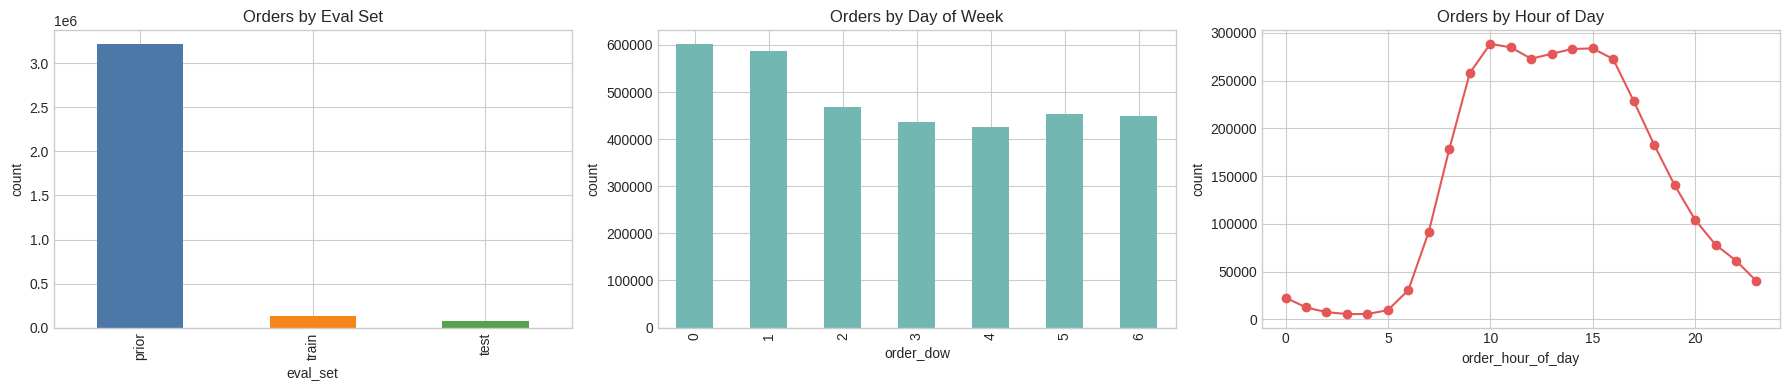

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

orders['eval_set'].value_counts().plot(kind='bar', ax=axes[0], color=['#4C78A8', '#F58518', '#54A24B'])
axes[0].set_title('Orders by Eval Set')
axes[0].set_xlabel('eval_set')
axes[0].set_ylabel('count')

orders['order_dow'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='#72B7B2')
axes[1].set_title('Orders by Day of Week')
axes[1].set_xlabel('order_dow')
axes[1].set_ylabel('count')

orders['order_hour_of_day'].value_counts().sort_index().plot(kind='line', ax=axes[2], color='#E45756', marker='o')
axes[2].set_title('Orders by Hour of Day')
axes[2].set_xlabel('order_hour_of_day')
axes[2].set_ylabel('count')

plt.tight_layout()
plt.show()

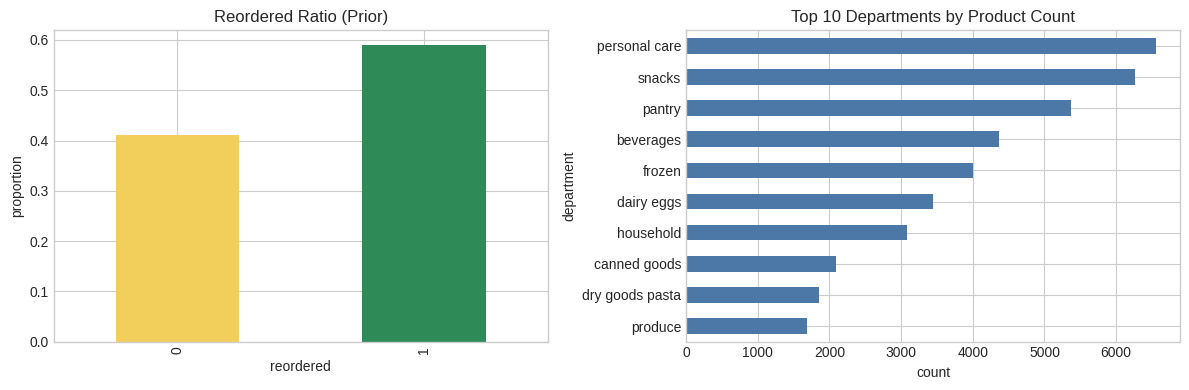

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

order_products_prior['reordered'].value_counts(normalize=True).sort_index().plot(
    kind='bar', ax=axes[0], color=['#F2CF5B', '#2E8B57']
)
axes[0].set_title('Reordered Ratio (Prior)')
axes[0].set_xlabel('reordered')
axes[0].set_ylabel('proportion')

# Top departments by number of product records
product_dept = products.merge(departments, on='department_id', how='left')
product_dept['department'].value_counts().head(10).sort_values().plot(kind='barh', ax=axes[1], color='#4C78A8')
axes[1].set_title('Top 10 Departments by Product Count')
axes[1].set_xlabel('count')
axes[1].set_ylabel('department')

plt.tight_layout()
plt.show()

## 6) Key Integrity Checks
Validate key uniqueness and relationship consistency across tables.

In [10]:
checks = {
    'orders.order_id_unique': orders['order_id'].is_unique,
    'products.product_id_unique': products['product_id'].is_unique,
    'aisles.aisle_id_unique': aisles['aisle_id'].is_unique,
    'departments.department_id_unique': departments['department_id'].is_unique,
    'prior.order_id_in_orders_pct': round(order_products_prior['order_id'].isin(orders['order_id']).mean() * 100, 2),
    'train.order_id_in_orders_pct': round(order_products_train['order_id'].isin(orders['order_id']).mean() * 100, 2),
    'prior.product_id_in_products_pct': round(order_products_prior['product_id'].isin(products['product_id']).mean() * 100, 2),
    'train.product_id_in_products_pct': round(order_products_train['product_id'].isin(products['product_id']).mean() * 100, 2),
}

pd.Series(checks, name='result')

orders.order_id_unique                 True
products.product_id_unique             True
aisles.aisle_id_unique                 True
departments.department_id_unique       True
prior.order_id_in_orders_pct       100.0000
train.order_id_in_orders_pct       100.0000
prior.product_id_in_products_pct   100.0000
train.product_id_in_products_pct   100.0000
Name: result, dtype: object

## 7) Findings and Next Actions
After running all cells, summarize in 4-6 bullets:
- biggest table and processing implication
- most significant missing-value pattern
- integrity check highlights
- one behavioral insight from time/reordered plots
- risks before feature engineering